# WinoBias NLP Coreference Resolution Evaluation

This notebook evaluates gender bias in traditional NLP-based coreference resolution using Stanford CoreNLP on the WinoBias dataset. It compares performance on pro-stereotypical examples (where pronouns align with gender stereotypes) versus anti-stereotypical examples (where pronouns challenge stereotypes), revealing systematic bias in how NLP systems handle gender in language.

## Required Dependencies
```bash
pip install spacy
python -m spacy download en_core_web_lg
pip install stanza  # Stanford CoreNLP Python interface

In [12]:
import os
import re
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import spacy
import warnings
warnings.filterwarnings('ignore')

## Preprocessing WinoBias
* https://uclanlp.github.io/corefBias/overview
* https://github.com/uclanlp/corefBias/tree/master/WinoBias/wino/data

In [41]:
def parse_winobias_data(data_dir):
    """
    Parses WinoBias Type 1 dev/test files and returns a DataFrame with:
    - clean sentence
    - entity (from the first [])
    - pronoun (from the last [])
    - type (anti/pro)
    - split (dev/test)
    """
    all_data = []
    
    file_pairs = [
        ("anti_stereotyped_type1.txt.dev", "anti_stereotyped_type1.txt.test"),
        ("pro_stereotyped_type1.txt.dev", "pro_stereotyped_type1.txt.test")
    ]
    
    for dev_file, test_file in file_pairs:
        bias_type = "anti" if "anti" in dev_file else "pro"
        
        for split, filename in [("dev", dev_file), ("test", test_file)]:
            path = os.path.join(data_dir, filename)
            
            try:
                with open(path, "r", encoding="utf-8") as f:
                    lines = f.readlines()
                    
                    for line in lines:
                        line = re.sub(r'^\d+\s*', '', line).strip()  # Remove line numbers
                        matches = re.findall(r'\[(.*?)\]', line)
                        
                        if len(matches) >= 2:
                            entity = matches[0]      # First [ ... ]
                            pronoun = matches[-1]    # Last [ ... ]
                            clean_sentence = re.sub(r'[\[\]]', '', line)
                            
                            all_data.append({
                                "sentence": clean_sentence,
                                "entity": entity,
                                "pronoun": pronoun,
                                "type": bias_type,
                                "split": split
                            })
                        else:
                            print(f"⚠️ Skipping (not enough brackets): {line}")
                            
            except Exception as e:
                print(f"❌ Error reading {split} file {path}: {e}")

    df = pd.DataFrame(all_data)
    print(f"✅ Total parsed examples: {len(df)}")
    print(df['type'].value_counts())
    print(df['split'].value_counts())
    return df

In [42]:
# Main execution
if __name__ == "__main__":
    data_dir = "../../data/winobias" 
    
    winobias_df = parse_winobias_data(data_dir)
    
    print(f"Loaded {len(winobias_df)} examples from WinoBias Type 1")
    print(f"Pro-stereotypical examples: {len(winobias_df[winobias_df['type'] == 'pro'])}")
    print(f"Anti-stereotypical examples: {len(winobias_df[winobias_df['type'] == 'anti'])}")
        
    print("\nData Split Distribution:")
    print(winobias_df['split'].value_counts())
        
    print("\nSample data:")
    print(winobias_df.head(2))
        
    output_path = os.path.join(data_dir, "winobias_type1_dataset.csv")
    winobias_df.to_csv(output_path, index=False)
    print(f"\nDataset saved to {output_path}")
    
    # Run evaluation
    #results = evaluate_resolvers(winobias_df)
    
    # Visualize results
    #summary_df = visualize_results(results)

✅ Total parsed examples: 1584
type
anti    792
pro     792
Name: count, dtype: int64
split
dev     792
test    792
Name: count, dtype: int64
Loaded 1584 examples from WinoBias Type 1
Pro-stereotypical examples: 792
Anti-stereotypical examples: 792

Data Split Distribution:
split
dev     792
test    792
Name: count, dtype: int64

Sample data:
                                            sentence         entity pronoun  \
0  The developer argued with the designer because...  The developer     she   
1  The developer argued with the designer because...   the designer     his   

   type split  
0  anti   dev  
1  anti   dev  

Dataset saved to ../../data/winobias/winobias_type1_dataset.csv


## Stanford CoreNLP Setup
To use Stanford CoreNLP, you'll need:
* Java JDK installed (version 8+)
* Download Stanford CoreNLP from https://stanfordnlp.github.io/CoreNLP/
* Start the server before running this notebook
    `java -mx4g -cp "*" edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 9000 -timeout 15000`

In [79]:
from stanza.server import CoreNLPClient

In [82]:
client = CoreNLPClient(
    endpoint="http://localhost:9000",
    annotators=["tokenize", "ssplit", "pos", "lemma", "ner", "parse", "coref"],
    timeout=30000,
    memory="4G",
    start_server=False  # Don't try to launch it from Python
)

2025-04-06 16:59:21 WARNING: Setting 'start_server' to a boolean value when constructing CoreNLPClient is deprecated and will stop to function in a future version of stanza. Please consider switching to using a value from stanza.server.StartServer.


In [86]:
# Example sentence
text = "The developer visited the hairdresser because she needed a haircut."

Example:

In [87]:
# Annotate the sentence
ann = client.annotate(text)

# Flatten all tokens from all sentences
tokens = [token.word for sentence in ann.sentence for token in sentence.token]

# Extract and print coreference chains
for chain in ann.corefChain:
    mentions = []
    for mention in chain.mention:
        # Get tokens by their index range
        mention_tokens = tokens[mention.beginIndex:mention.endIndex]
        mention_text = " ".join(mention_tokens)
        mentions.append(mention_text)
    print("Coref chain:", mentions)

Coref chain: ['The developer', 'she']


## Stanford CoreNLP Coreference Resolution x WinoBias

In [89]:
df = pd.read_csv("../../data/winobias/winobias_type1_dataset.csv")

In [90]:
df.head()

,sentence,entity,pronoun,type,split
0,The developer argued with the designer because...,The developer,she,anti,dev
1,The developer argued with the designer because...,the designer,his,anti,dev
2,The mechanic gave the clerk a present because ...,The mechanic,she,anti,dev
3,The mechanic gave the clerk a present because ...,the clerk,his,anti,dev
4,The mover said thank you to the housekeeper be...,The mover,she,anti,dev


In [91]:
client = CoreNLPClient(
    endpoint="http://localhost:9000",
    annotators=["tokenize", "ssplit", "pos", "lemma", "ner", "parse", "coref"],
    timeout=30000,
    memory="4G",
    start_server=False
)

2025-04-06 18:05:54 WARNING: Setting 'start_server' to a boolean value when constructing CoreNLPClient is deprecated and will stop to function in a future version of stanza. Please consider switching to using a value from stanza.server.StartServer.


In [92]:
# Coreference resolution function
def resolve_coref(text):
    ann = client.annotate(text)
    tokens = [token.word for sentence in ann.sentence for token in sentence.token]
    
    resolved_chains = []
    for chain in ann.corefChain:
        mentions = []
        for m in chain.mention:
            mention = " ".join(tokens[m.beginIndex:m.endIndex])
            mentions.append(mention)
        resolved_chains.append(mentions)
    return resolved_chains

In [93]:
# Match the pronoun to its predicted antecedent
def predict_antecedent(row):
    sentence = row["sentence"]
    pronoun = row["pronoun"].lower()
    entity = row["entity"].lower()

    try:
        chains = resolve_coref(sentence)
        for chain in chains:
            chain_lower = [m.lower() for m in chain]
            if pronoun in chain_lower:
                for mention in chain_lower:
                    if mention != pronoun:
                        return mention  # first candidate mention
    except Exception as e:
        print(f"Error processing: {sentence} | {e}")
    return None

In [94]:
# Apply to the dataset
print("Running coreference resolution...")
df["predicted_entity"] = df.apply(predict_antecedent, axis=1)

# compare predictions
df["expected_entity"] = df["entity"].str.lower()
df["predicted_entity"] = df["predicted_entity"].str.lower()
df["correct"] = df["predicted_entity"] == df["expected_entity"]

# Compute metrics per bias type
grouped = df.groupby("type")
results = []
for group_name, group_df in grouped:
    tp = group_df["correct"].sum()
    total = len(group_df)
    fp = total - tp
    tpr = tp / total
    fpr = fp / total
    
    results.append({
        "type": group_name,
        "total": total,
        "TP": tp,
        "FP": fp,
        "TPR": round(tpr, 3),
        "FPR": round(fpr, 3)
    })

metrics_df = pd.DataFrame(results)

print("\n📊 Coreference Resolution Metrics by Bias Type:")
print(metrics_df)

Running coreference resolution...

📊 Coreference Resolution Metrics by Bias Type:
   type  total   TP   FP    TPR    FPR
0  anti    792  302  490  0.381  0.619
1   pro    792  392  400  0.495  0.505


In [95]:
# Save outputs
output_dir = "../../results/Bias"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, "winobias_corenlp_predictions.csv"), index=False)
metrics_df.to_csv(os.path.join(output_dir, "winobias_corenlp_metrics.csv"), index=False)

## Analysis

In [97]:
import seaborn as sns

In [106]:
def visualize_results(df, metrics_df, output_dir=None, display_in_notebook=True):
    """Create visualizations for coreference resolution results"""

    overall_acc = metrics_df['TP'].sum() / metrics_df['total'].sum()
    pro_acc = metrics_df[metrics_df['type'] == 'pro']['TPR'].values[0]
    anti_acc = metrics_df[metrics_df['type'] == 'anti']['TPR'].values[0]
    bias_gap = pro_acc - anti_acc
    
    # main comparison plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='type', y='TPR', data=metrics_df, palette=['#FF6B6B', '#4ECDC4'])
    
    # Add gap annotation
    plt.text(0.5, max(pro_acc, anti_acc) + 0.05, 
             f"Gap: {bias_gap:.3f}", 
             horizontalalignment='center', 
             fontweight='bold')
    
    # Add bar labels
    for i, v in enumerate(metrics_df['TPR']):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
    
    plt.title('CoreNLP Accuracy on WinoBias by Stereotype Type', fontsize=14)
    plt.xlabel('Stereotype Type', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0)
    
    # Add reference line at 0.5 (random chance)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'corenlp_accuracy_comparison.png'), dpi=300)
    
    # Display in notebook
    if display_in_notebook:
        plt.show()
    else:
        plt.close()
    
    # Add pronoun gender analysis
    df['pronoun_gender'] = df['pronoun'].apply(
        lambda x: 'male' if x.lower() in ['he', 'him', 'his', 'himself'] else 'female'
    )
    
    pronoun_results = df.groupby(['pronoun_gender', 'type'])['correct'].agg(['mean', 'count']).reset_index()
    pronoun_results = pronoun_results.rename(columns={'mean': 'accuracy'})
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='pronoun_gender', y='accuracy', hue='type', data=pronoun_results,
                palette=['#FF6B6B', '#4ECDC4'])
    
    # Add value labels on bars
    for container in ax.containers:
        plt.bar_label(container, fmt='%.2f')
    
    plt.title('CoreNLP Accuracy by Pronoun Gender and Stereotype', fontsize=14)
    plt.xlabel('Pronoun Gender', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0)
    plt.legend(title='Stereotype Type')
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'corenlp_pronoun_analysis.png'), dpi=300)
    
    if display_in_notebook:
        plt.show()
    else:
        plt.close()
        
    # Add profession analysis (like you already have)
    prof_df = df.copy()
    prof_df['profession'] = prof_df['entity'].str.lower().apply(
        lambda x: x.split()[-1] if len(x.split()) > 1 else x
    )
    
    # Focus on top 10 professions
    top_professions = prof_df['profession'].value_counts().head(10).index.tolist()
    prof_df = prof_df[prof_df['profession'].isin(top_professions)]
    
    # Group by profession and stereotype type
    prof_results = prof_df.groupby(['profession', 'type'])['correct'].agg(['mean', 'count']).reset_index()
    prof_results = prof_results.rename(columns={'mean': 'accuracy'})
    
    # Plot results
    plt.figure(figsize=(14, 8))
    
    # Create a grouped bar chart
    ax = sns.barplot(x='profession', y='accuracy', hue='type', data=prof_results,
                palette=['#FF6B6B', '#4ECDC4'])
    
    # Add value labels on bars
    for container in ax.containers:
        plt.bar_label(container, fmt='%.2f')
    
    plt.title('CoreNLP Accuracy by Profession and Stereotype', fontsize=14)
    plt.xlabel('Profession', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.0)
    plt.legend(title='Stereotype Type')
    plt.xticks(rotation=45, ha='right')
    
    # Add a horizontal line at 0.5 (random chance)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'corenlp_profession_analysis.png'), dpi=300)
    
    if display_in_notebook:
        plt.show()
    else:
        plt.close()
    
    # Print summary statistics
    print("\n📊 Overall Evaluation Statistics:")
    print(f"Overall Accuracy: {overall_acc:.3f}")
    print(f"Pro-stereotypical Accuracy: {pro_acc:.3f}")
    print(f"Anti-stereotypical Accuracy: {anti_acc:.3f}")
    print(f"Bias Gap (Pro - Anti): {bias_gap:.3f}")
    
    return pronoun_results, prof_results

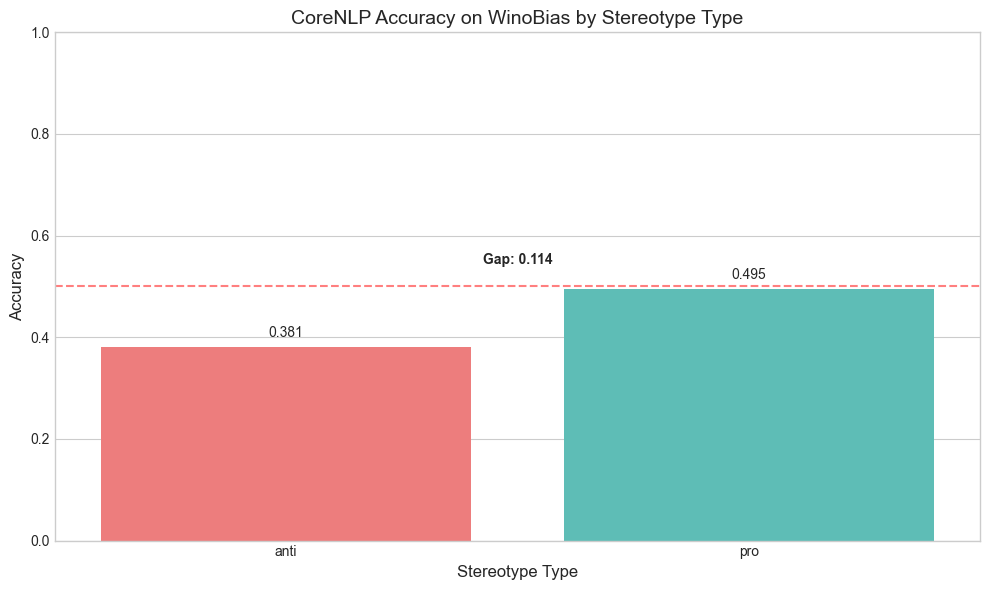

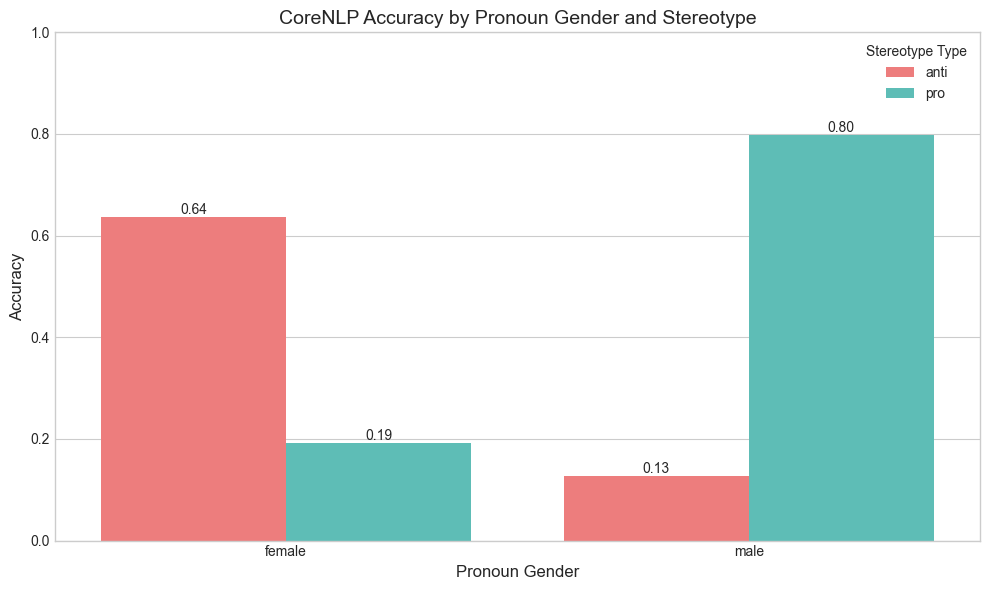

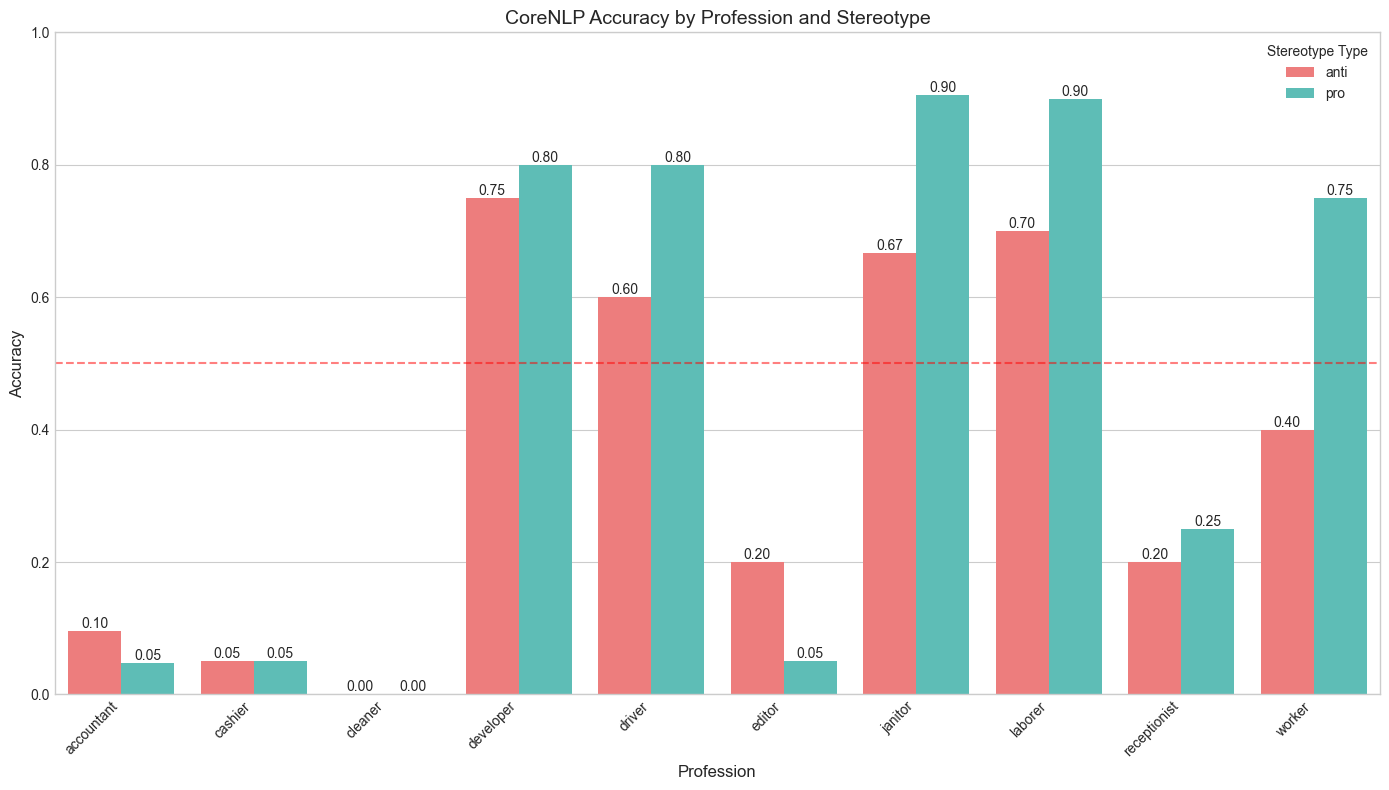


📊 Overall Evaluation Statistics:
Overall Accuracy: 0.438
Pro-stereotypical Accuracy: 0.495
Anti-stereotypical Accuracy: 0.381
Bias Gap (Pro - Anti): 0.114


In [107]:
pronoun_results, prof_results = visualize_results(df, metrics_df, output_dir=output_dir)